In [140]:
!pip install torch torchvision torchaudio
# !pip install ipywidgets

In [141]:
import kagglehub
from pathlib import Path

# Downloading the data set
print(" Downloading MediScan dataset...")
path = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")

print(f" Data ready at: {path}")


dataset_path = Path(path)
image_path = dataset_path / "images"
csv_path = dataset_path / "Data_Entry_2017.csv"

 Data ready at: /Users/sdhakal8/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3


In [142]:
import pandas as pd
import os
from pathlib import Path


dataset_path = Path(path)
image_path = dataset_path / "images"
csv_path = dataset_path / "Data_Entry_2017.csv"


#printinh the images and csv file path location
print(f" Images are here: {image_path}")
print(f" CSV is here: {csv_path}")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"\n Success! Loaded CSV with {len(df)} rows.")
    print("Here is a preview of the data:")
    print(df[['Image Index', 'Finding Labels']].head(5))
else:
    print("Error: CSV file not found. Check the path.")

 Images are here: /Users/sdhakal8/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/images
 CSV is here: /Users/sdhakal8/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/Data_Entry_2017.csv

 Success! Loaded CSV with 112120 rows.
Here is a preview of the data:
        Image Index          Finding Labels
0  00000001_000.png            Cardiomegaly
1  00000001_001.png  Cardiomegaly|Emphysema
2  00000001_002.png   Cardiomegaly|Effusion
3  00000002_000.png              No Finding
4  00000003_000.png                  Hernia


In [143]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import os

#writing a custom dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
      #Initialize our custom data set
        self.labels_frame = dataframe
        self.root_dir = root_dir
        self.transform = transform

       #classification is going to be done with these labels
        self.all_labels = [
            'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule',
            'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema',
            'Fibrosis', 'Pleural_Thickening', 'Hernia', 'No Finding'
        ]

    def __len__(self):
        return len(self.labels_frame)

    def __getitem__(self, idx):
        # 1. Get Image Path
        img_name = os.path.join(self.root_dir, self.labels_frame.iloc[idx, 0])
        image = Image.open(img_name).convert('RGB')

        # 2. Get Labels (Multi-Hot Encoding)
        label_str = self.labels_frame.iloc[idx, 1]

        # Check against ALL 15 labels
        label_vec = torch.tensor(
            [1.0 if disease in label_str else 0.0 for disease in self.all_labels],
            dtype=torch.float32
        )

        # 3. Transform
        if self.transform:
            image = self.transform(image)

        return image, label_vec

In [144]:
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, random_split

image_path = os.path.join(path, "images-224", "images-224")
# 2. Defining Transforms (Normalizing using ImageNet stats)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        
        transforms.RandomRotation(10), 
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),

        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


train_dataset = ChestXrayDataset(
    dataframe=train_df,
    root_dir=image_path,
    transform=data_transforms['train']
)

test_dataset = ChestXrayDataset(
    dataframe=test_df,
    root_dir=image_path,
    transform=data_transforms['val']
)


# 5. Create DataLoaders for differnet batchsize for backward propagation
BATCHSIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCHSIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=False)

print(f"  Data Ready!")
print(f"   - Training Images: {len(train_dataset)}")
print(f"   - Testing Images:  {len(test_dataset)}")

# 6. Sanity Check (Force it to load one batch to prove it works)
try:
    images, labels = next(iter(train_loader))
    print(f" SUCCESS! Batch loaded with shape: {images.shape}")
except Exception as e:
    print(f" ERROR: {e}")

  Data Ready!
   - Training Images: 89696
   - Testing Images:  22424
 SUCCESS! Batch loaded with shape: torch.Size([32, 3, 224, 224])


In [145]:
#watching the images
import random
from PIL import Image
from pathlib import Path # Import Path class from pathlib


# Convert the image_path string to a Path object before calling .glob()
image_path_obj = Path(image_path)
# Adjusted glob pattern to look for .png files directly within image_path_obj
image_path_list = list(image_path_obj.glob("*.png"))


Running Integrity Check on Train Set...
--- CHECKING INDEX 28831 ---
File:  00010200_001.png
CSV Says:    Nodule
Loader Says: Nodule
MATCH! The data is correct.


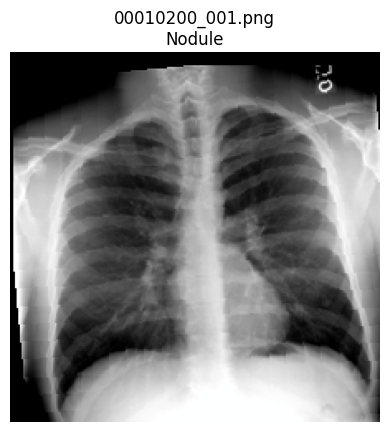


Running Visual Check on Train Loader...
Showing 5 Random Augmented Images...


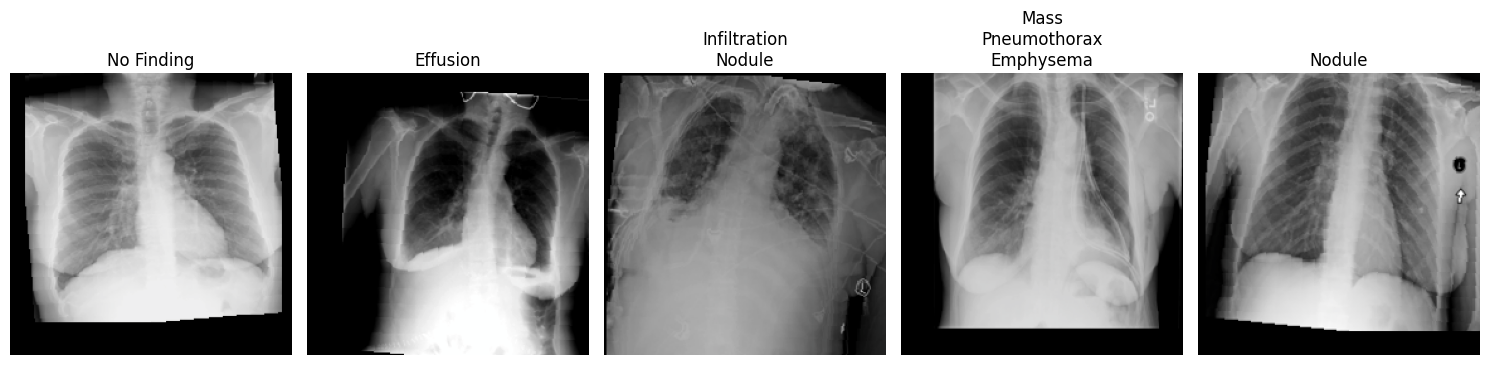

In [146]:
import matplotlib.pyplot as plt
import numpy as np
import random

def show_image(tensor):
    image = tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    return np.clip(image, 0, 1)

# Checks if the CSV file matches the Image Loader
def check_data_match(dataset, dataframe):
    # Pick a random number
    idx = random.randint(0, len(dataset) - 1)

    # A. Get the Data from the Loader
    image, label_vector = dataset[idx]

    # B. Get the Data from the CSV File
    filename = dataframe.iloc[idx]['Image Index']
    csv_label = dataframe.iloc[idx]['Finding Labels']

    # C. Convert the Loader's math vector back to English words
    class_names = dataset.all_labels
    active_labels = [class_names[i] for i, value in enumerate(label_vector) if value == 1]
    dataset_label = "|".join(active_labels) if active_labels else "No Finding"

    # D. Comparing them
    print(f"--- CHECKING INDEX {idx} ---")
    print(f"File:  {filename}")
    print(f"CSV Says:    {csv_label}")
    print(f"Loader Says: {dataset_label}")

    if csv_label == dataset_label:
        print("MATCH! The data is correct.")
    else:
        print(" ERROR! The data is mixed up.")

    # Show the picture
    plt.imshow(show_image(image))
    plt.title(f"{filename}\n{dataset_label}")
    plt.axis('off')
    plt.show()

# --- 3. THE "WHAT DOES THE ROBOT SEE?" TEST ---
# Shows a batch of images after rotation/flipping
def show_batch(loader, class_names):
    # Grab one bag of images (32 images)
    images, labels = next(iter(loader))

    plt.figure(figsize=(15, 5))
    print(f"Showing 5 Random Augmented Images...")

    # Show the first 5
    for i in range(5):
        plt.subplot(1, 5, i + 1)

        # Get the label name
        label_vec = labels[i]
        active = [class_names[j] for j, val in enumerate(label_vec) if val == 1]
        title = "\n".join(active) if active else "No Finding"

        # Plot it
        plt.imshow(show_image(images[i]))
        plt.title(title)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# --- RUN THE TESTS ---
print("Running Integrity Check on Train Set...")
check_data_match(train_dataset, train_df)

print("\nRunning Visual Check on Train Loader...")
show_batch(train_loader, train_dataset.all_labels)

In [147]:
import torch
import torch.nn as nn
from torchvision import models

#Device agnostic code
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class ModelV1(nn.Module):
    """
    ModelV1: A wrapper for DenseNet121 using Transfer Learning.
    Args:
        output_shape (int): The number of diseases to predict.
    """
    def __init__(self, output_shape: int):
        super().__init__()

        # 1. Load the Pretrained Model (The "Brain")
        self.densenet = models.densenet121(weights='DEFAULT')

        # 2. Freeze the "Body" (Feature Extractor)
        # We don't want to destroy the patterns it learned from ImageNet.
        for param in self.densenet.features.parameters():
            param.requires_grad = False

        # 3. Replace the "Head" (Classifier)
        # DenseNet121's feature extractor outputs 1024 features.

        self.densenet.classifier = nn.Linear(in_features=1024, out_features=output_shape)

    def forward(self, x):
        return self.densenet(x)



In [148]:
#Instantiating the model:
modelA = ModelV1(output_shape=15).to(device)

print(f"✅ ModelV1 created successfully on {device}!")
print(modelA)


✅ ModelV1 created successfully on cpu!
ModelV1(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1):

In [149]:
# get a single image batch and label match
# we will chek image batch batch and label batch shape

In [150]:
image_batch, label_batch = next(iter(train_loader))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32, 15]))

In [151]:
# Move the input to the same device as the model before prediction
(modelA(image_batch.to(device))).shape

torch.Size([32, 15])

In [152]:
#install torch info

try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

In [153]:
from torchinfo import summary
print(summary(modelA))
#Input: 1024 features (from DenseNet)Output: 15 diseasesBias: 15 (one per output)Formula: $(1024 \times 15) + 15 = 15,375$.
print(summary(modelA, input_size=(1, 3, 224, 224)))

Layer (type:depth-idx)                        Param #
ModelV1                                       --
├─DenseNet: 1-1                               --
│    └─Sequential: 2-1                        --
│    │    └─Conv2d: 3-1                       (9,408)
│    │    └─BatchNorm2d: 3-2                  (128)
│    │    └─ReLU: 3-3                         --
│    │    └─MaxPool2d: 3-4                    --
│    │    └─_DenseBlock: 3-5                  (335,040)
│    │    └─_Transition: 3-6                  (33,280)
│    │    └─_DenseBlock: 3-7                  (919,680)
│    │    └─_Transition: 3-8                  (132,096)
│    │    └─_DenseBlock: 3-9                  (2,837,760)
│    │    └─_Transition: 3-10                 (526,336)
│    │    └─_DenseBlock: 3-11                 (2,158,080)
│    │    └─BatchNorm2d: 3-12                 (2,048)
│    └─Linear: 2-2                            15,375
Total params: 6,969,231
Trainable params: 15,375
Non-trainable params: 6,953,856
Layer (type:

In [154]:
import torch.nn.functional as F
def train_step(model: torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):

  model.train()

  train_loss, train_acc = 0, 0

  for batch, (X,y) in enumerate(dataloader):
    X,y = X.to(device), y.to(device)

      
    if y.ndim == 1: 
            y = F.one_hot(y.long(), num_classes=15).float()
    else:
            y = y.float()
      
    #Do the forward pass
    y_pred = model(X) #This outputs model logits

    #Calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()

    #Optimizer zero grad
    optimizer.zero_grad()

    #loss backward
    loss.backward()

    #Optimizer step
    optimizer.step()

    # Calculate multi-label accuracy
    y_prob = torch.sigmoid(y_pred) # Convert logits to probabilities
    y_pred_binary = (y_prob > 0.5).float() # Threshold probabilities to get binary predictions
    # Calculate element-wise accuracy over all labels and samples in the batch
    train_acc += (y_pred_binary == y).float().mean().item()


  train_loss = train_loss / len(dataloader)
  train_acc = train_acc/len(dataloader)
  return train_loss, train_acc



In [155]:
import torch.nn.functional as F
def test_step(model: torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device = device):
    with torch.inference_mode():
        model.eval()
        test_loss, test_acc, test_recall = 0, 0, 0

        for batch, (X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)

            if y.ndim == 1: 
                y = F.one_hot(y.long(), num_classes=15).float()
            else:
                y = y.float()
            
            # Do the forward pass
            test_preds_logits = model(X)
            loss = loss_fn(test_preds_logits, y)
            test_loss += loss.item()

            # 3. Predictions (Sigmoid + Threshold)
            test_prob = torch.sigmoid(test_preds_logits)
            test_pred_binary = (test_prob > 0.5).float()

            # 4. Accuracy
            test_acc += (test_pred_binary == y).float().mean().item()

            # 5. RECALL FORMULA
            # Logic: (True Positives) / (All Actual Positives)
            # We add 1e-8 to avoid dividing by zero if there are no diseases in the batch
            true_positives = ((test_pred_binary == 1) & (y == 1)).float().sum()
            actual_positives = (y == 1).float().sum()
            test_recall += (true_positives / (actual_positives + 1e-8)).item()

        # Average over batches
        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        test_recall = test_recall / len(dataloader)

        return test_loss, test_acc, test_recall

In [156]:
def train_test_function(model: torch.nn.Module,
                        train_dataloader: torch.utils.data.DataLoader,
                        test_dataloader: torch.utils.data.DataLoader,
                        optimizer: torch.optim.Optimizer,
                        loss_fn,
                        Epochs: int = 5,
                        device=device):

    # Initialize results dictionary
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "test_recall": []
    }

    from timeit import default_timer as timer
    from tqdm.auto import tqdm

    for epoch in tqdm(range(Epochs)):
        train_time_start = timer()


        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)

        train_time_end_ep1 = timer()
        print(f"Epoch {epoch} for training is finished at {train_time_end_ep1-train_time_start}")
        test_loss, test_acc, test_recall = test_step(model=model,
                                                     dataloader=test_dataloader,
                                                     loss_fn=loss_fn,
                                                     device=device)

        

        print(f"\nEpoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | "
              f"train_acc: {train_acc:.4f} | "
              f"test_loss: {test_loss:.4f} | "
              f"test_acc: {test_acc:.4f} | "
              f"Recall: {test_recall:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        results["test_recall"].append(test_recall)

    return results

In [157]:
try:
  from tqdm.auto import tqdm
except ModuleNotFoundError:
  !pip install tqdm
  from tqdm.auto import tqdm

In [158]:
##Loss and optimizer functions

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(modelA.parameters(), lr=0.001)

In [159]:
import torch

def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("🍏 Success! Using Apple MPS (M-Series Chip).")

    # 2. Secondary: Check for NVIDIA GPU (Colab / Windows)
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("🔥 Using NVIDIA CUDA (Colab/Dedicated GPU).")

    # 3. Fallback: CPU (Slow but reliable)
    else:
        device = torch.device("cpu")
        print("🐢 Using CPU (Slow Fallback).")

    return device

# Set the device
device = get_device()
print(f"🚀 Active Device: {device}")

🍏 Success! Using Apple MPS (M-Series Chip).
🚀 Active Device: mps


In [160]:
import torch
import platform

print(f"Python Platform: {platform.machine()}")
print(f"PyTorch Version: {torch.__version__}")
print(f"MPS Built? {torch.backends.mps.is_built()}")
print(f"MPS Available? {torch.backends.mps.is_available()}")

Python Platform: arm64
PyTorch Version: 2.10.0
MPS Built? True
MPS Available? True


In [161]:
EPOCHS = 5
modelA.to(device)
results = train_test_function(
    model=modelA,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    Epochs=EPOCHS,
    device=device
)


  0%|          | 0/5 [00:00<?, ?it/s]

KeyboardInterrupt: 

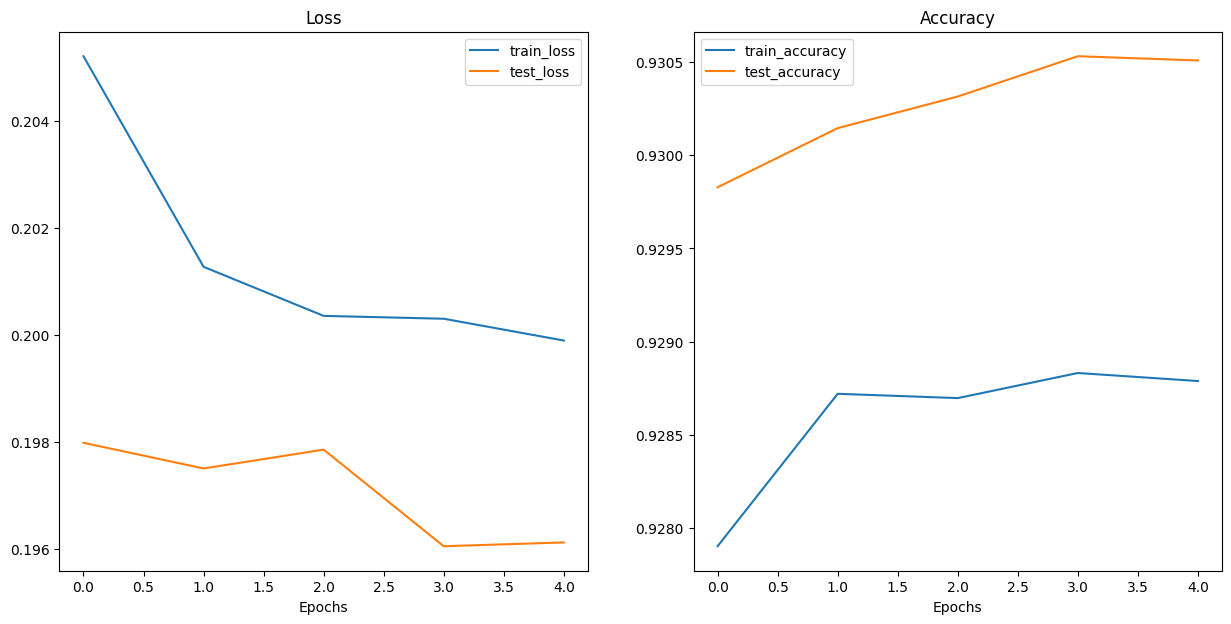

In [162]:
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup a plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

plot_loss_curves(results)

In [163]:
#Since the recall is high, we are trying to ge the recall down from the model

In [164]:
print(results)


{'train_loss': [0.2052082415222271, 0.20126922618660212, 0.20035194970010817, 0.20029842768487785, 0.19989071279509], 'train_acc': [0.9279039305233759, 0.9287207633990541, 0.9286977227696172, 0.9288322513672526, 0.9287891433020383], 'test_loss': [0.19797812623321245, 0.19749823560175644, 0.19785004006047732, 0.19604388999615857, 0.19611496333771528], 'test_acc': [0.9298274772143398, 0.9301444849852318, 0.9303138845317204, 0.9305298471246738, 0.9305070618249891], 'test_recall': [0.3637381992734618, 0.35539361136233416, 0.3193539936260218, 0.3356169430424756, 0.34536376477520747]}


In [165]:
# 2. Define Model V2 (The Specialist)
class ModelV2(nn.Module):
    """
    ModelV2: An upgraded DenseNet121 with Fine-Tuning and Dropout.
    Args:
        output_shape (int): The number of diseases to predict.
    """
    def __init__(self, output_shape: int):
        super().__init__()

        # Load the Pretrained Brain
        self.densenet = models.densenet121(weights='DEFAULT')

        # UPGRADE 1: Fine-Tuning
        # We freeze the early layers (simple edges/shapes)
        for param in self.densenet.features.parameters():
            param.requires_grad = False
            
        # ... BUT we UNFREEZE the last "Dense Block".
        # This allows the model to learn high-level X-ray concepts (haze, consolidation).
        for param in self.densenet.features.denseblock4.parameters():
            param.requires_grad = True
        for param in self.densenet.features.norm5.parameters():
            param.requires_grad = True

        # UPGRADE 2: A Deeper, Safer Head
        # Old Head: 1024 -> 15
        # New Head: 1024 -> 512 -> ReLU -> Dropout -> 15
        self.densenet.classifier = nn.Sequential(
            nn.Linear(1024, 512),            # Squeeze features down
            nn.ReLU(),                       # Activation
            nn.Dropout(p=0.2),               # Randomly drop 20% to prevent memorization
            nn.Linear(512, output_shape)     # Final prediction
        )

    def forward(self, x):
        return self.densenet(x)

# 3. Instantiate Model B
modelB = ModelV2(output_shape=15).to(device)

print(f"✅ ModelV2 (modelB) created on {device}!")
print("Last block is unfrozen for fine-tuning.")

✅ ModelV2 (modelB) created on mps!
Last block is unfrozen for fine-tuning.


In [166]:

optimizerB = torch.optim.Adam(modelB.parameters(), lr=1e-4)


positive_counts = df.iloc[:, 1].str.get_dummies(sep='|').sum()
pos_weights = torch.tensor(len(df) / (positive_counts.values + 1e-6)).float().to(device)
loss_fn_B = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)

print("Ready to train Model B!")

Ready to train Model B!


In [167]:

optimizerB = torch.optim.Adam(modelB.parameters(), lr=1e-4)
positive_counts = df.iloc[:, 1].str.get_dummies(sep='|').sum()
pos_weights = torch.tensor(len(df) / (positive_counts.values + 1e-6)).float().to(device)
loss_fn_B = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)



In [ ]:
# 2. Running the loop
resultsB = train_test_function(
    model=modelB,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    optimizer=optimizerB,
    loss_fn=loss_fn_B, # The weighted loss function
    Epochs=5,
    device=device
)

  0%|          | 0/5 [00:00<?, ?it/s]